## 7.20 양자 화학에서의 카이랄성과 원편광 이색성(CD)

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Operator, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

%matplotlib inline

In [10]:
# 상수 정의
wavelength = 400e-9  # 빛의 파장(m) (자외선 예시)
frequency = 3e8 / wavelength  # 빛의 주파수(Hz)
omega = 2 * np.pi * frequency  # 각주파수
g = 0.05  # 결합 세기 (임의 단위)

In [11]:
# 좌·우 원편광에 대한 상호작용 해밀토니안 정의
H_left = SparsePauliOp(["XX", "YY"], coeffs=[g, -g])  # 좌원편광
H_right = SparsePauliOp(["XX", "YY"], coeffs=[g, g])  # 우원편광

In [12]:
# 카이랄 분자를 표현하는 2큐비트 양자회로 정의
qc = QuantumCircuit(2)
qc.h(0)  # 큐비트 0을 중첩으로 초기화
qc.x(1)  # 큐비트 1을 |1⟩ 상태(들뜬 상태)로 초기화

In [13]:
# 시뮬레이터 초기화
simulator = AerSimulator()

In [14]:
# 흡수 세기를 계산하는 함수 정의
def calculate_absorption(hamiltonian, circuit, time_points):
    intensities = []
    for t in time_points:
        # 시간 진화용 Pauli Evolution Gate 정의
        evolution_gate = PauliEvolutionGate(hamiltonian, time=t)
        U = Operator(evolution_gate).data  # 진화의 행렬 표현
        # 양자 상태에 진화 적용
        evolved_circuit = circuit.copy()
        evolved_circuit.unitary(U, [0, 1])  # 큐비트 0,1에 진화 적용
        evolved_circuit.save_statevector()  # 상태벡터 저장
        # 상태벡터 시뮬레이션
        result = simulator.run(evolved_circuit).result()
        statevector = result.data(0)["statevector"]  # 저장된 상태벡터 회수
        # 흡수 세기 계산 (|<ψ|H|ψ>|^2)
        statevector_array = np.array(statevector)
        intensity = np.abs(statevector_array.conj().T @ hamiltonian.to_matrix() @ statevector_array)**2
        intensities.append(intensity)
    return intensities

In [15]:
# 여러 시간점에 대해 시뮬레이션
time_points = np.linspace(0, 10, 100)  # 시뮬레이션 시간점
absorption_left = calculate_absorption(H_left, qc, time_points)
absorption_right = calculate_absorption(H_right, qc, time_points)

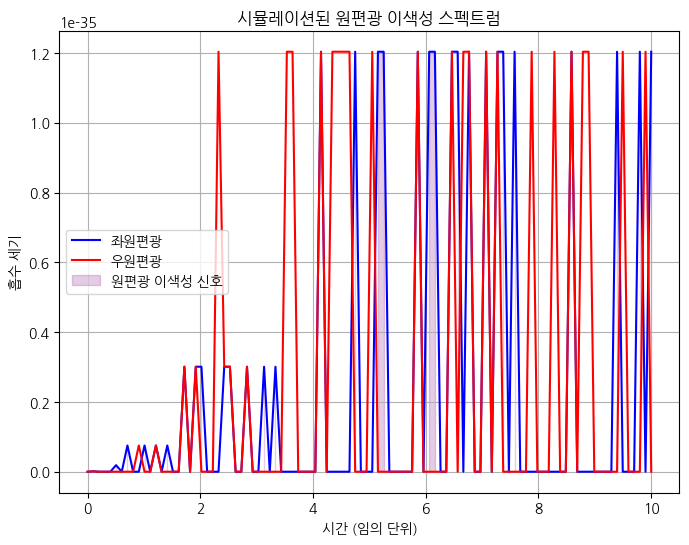

In [16]:
# 원편광 이색성(CD) 스펙트럼 플롯
plt.figure(figsize=(8, 6))
plt.plot(time_points, absorption_left, label="좌원편광", color="blue")
plt.plot(time_points, absorption_right, label="우원편광", color="red")
plt.fill_between(
    time_points,
    absorption_left,
    absorption_right,
    where=(np.array(absorption_left) > np.array(absorption_right)),
    color="purple",
    alpha=0.2,
    label="원편광 이색성 신호",
)
plt.xlabel("시간 (임의 단위)")
plt.ylabel("흡수 세기")
plt.title("시뮬레이션된 원편광 이색성 스펙트럼")
plt.legend()
plt.grid()
plt.show()